# Notebook 01 — Exploratory Data Analysis (EDA)

## Research Questions
1. **Q1 (Estimasi):** Berapa probabilitas sebuah PR di-merge, dan seberapa tidak pasti estimasi tersebut?
2. **Q2 (Inferensi):** Apakah rata-rata jumlah komentar berbeda secara signifikan antara PR yang merged vs unmerged?
3. **Q3 (Simulasi):** Berapa probabilitas sebuah issue butuh lebih dari 30 hari untuk ditutup?

## Member
- **Nama:** Kirana Cinta Mentari
- **Role:** Data Engineer (Member A)
- **Repository:** pandas-dev/pandas

## AI Usage Disclosure

**Member:** Kirana Cinta Mentari — Data Engineer (Member A)  
**Tools used:** Claude

| Task | Tool | Prompt summary | Output modified? |
|---|---|---|---|
| Membuat kode cleaning data | Claude | "Cara cleaning data GitHub issues dan PR" | Yes — disesuaikan dengan data |
| Membuat visualisasi EDA | Claude | "Buat visualisasi untuk research questions" | Yes — disesuaikan |
| Debugging error library | Claude | "Fix ModuleNotFoundError matplotlib" | Yes — dijalankan sendiri |

**Written entirely without AI:** Interpretasi hasil visualisasi, variable selection

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_issues = pd.read_csv('../data/raw/issues.csv')
df_pr = pd.read_csv('../data/raw/pr_all.csv')

df_issues['created_at'] = pd.to_datetime(df_issues['created_at'], utc=True)
df_issues['closed_at'] = pd.to_datetime(df_issues['closed_at'], utc=True)
df_pr['created_at'] = pd.to_datetime(df_pr['created_at'], utc=True)
df_pr['closed_at'] = pd.to_datetime(df_pr['closed_at'], utc=True)

print("Issues shape:", df_issues.shape)
print("PR shape:", df_pr.shape)

Issues shape: (1700, 37)
PR shape: (789, 10)


In [30]:
df_issues_clean = df_issues[[
    'number', 'title', 'state',
    'created_at', 'closed_at',
    'comments', 'author_association',
    'state_reason', 'labels'
]]
df_issues_clean = df_issues_clean.drop_duplicates()
print("Issues bersih:", df_issues_clean.shape)
print(df_issues_clean.isnull().sum())
df_issues_clean.head()

Issues bersih: (1700, 9)
number                   0
title                    0
state                    0
created_at               0
closed_at              338
comments                 0
author_association       0
state_reason          1571
labels                   0
dtype: int64


,number,title,state,created_at,closed_at,comments,author_association,state_reason,labels
0,65717,CI: Update pixi.lock,open,2026-05-24 05:34:32+00:00,NaT,0,CONTRIBUTOR,NaN,"[{'id': 48070600, 'node_id': 'MDU6TGFiZWw0ODA3..."
1,65716,BUG: DataFrame.update warns when index dtype m...,closed,2026-05-23 23:05:41+00:00,2026-05-24 04:28:42+00:00,0,NONE,NaN,[]
2,65715,DOC: fix incorrect alignment description in wh...,open,2026-05-23 19:32:56+00:00,NaT,0,NONE,NaN,[]
3,65714,BUG: raise on melt output-name collisions for ...,open,2026-05-23 19:21:35+00:00,NaT,0,NONE,NaN,[]
4,65713,BUG: handle chained Path division with Arrow s...,open,2026-05-23 10:19:50+00:00,NaT,0,NONE,NaN,[]


In [31]:
df_pr_clean = df_pr[[
    'number', 'title', 'status',
    'created_at', 'closed_at',
    'comments', 'user'
]]
df_pr_clean = df_pr_clean.drop_duplicates()
print("PR bersih:", df_pr_clean.shape)
print(df_pr_clean.isnull().sum())
df_pr_clean.head()

PR bersih: (789, 7)
number          0
title           0
status          0
created_at      0
closed_at     289
comments        0
user            0
dtype: int64


,number,title,status,created_at,closed_at,comments,user
0,65697,"Revert ""BUG: reject unhashable elements in Ind...",merged,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,1,jorisvandenbossche
1,65693,[backport 3.0.x] TST: Adjust xfails for fastpa...,merged,2026-05-20 14:03:23+00:00,2026-05-20 16:33:10+00:00,0,jorisvandenbossche
2,65686,BUG: Fix Index.where raising AssertionError wh...,merged,2026-05-19 18:54:58+00:00,2026-05-21 14:34:32+00:00,7,anzinmhd
3,65681,ASV: garbage collect as part of setup,merged,2026-05-18 21:24:09+00:00,2026-05-23 17:26:56+00:00,1,rhshadrach
4,65680,Bump github/codeql-action from 4.35.4 to 4.35.5,merged,2026-05-18 13:54:43+00:00,2026-05-18 15:27:45+00:00,0,dependabot[bot]


In [32]:
import os
os.makedirs('../data/clean', exist_ok=True)

df_issues_clean.to_csv('../data/clean/issues_clean.csv', index=False)
df_pr_clean.to_csv('../data/clean/pr_clean.csv', index=False)
print("Data bersih berhasil disimpan!")

Data bersih berhasil disimpan!


## Variable Selection

**Member A — Kirana Cinta Mentari | Data Engineer**

Dari dataset PR (`pr_clean.csv`) dan Issues (`issues_clean.csv`), dipilih beberapa variabel yang dianggap paling relevan untuk analisis statistik dan EDA.

### Dataset PR

| Variabel | Tipe | Digunakan untuk |
|---|---|---|
| `status` | Kategorikal (merged/unmerged) | Q1 — menghitung peluang PR di-merge menggunakan MLE Bernoulli (Member B) |
| `comments` | Numerik | Q2 — membandingkan jumlah komentar pada PR merged dan unmerged dengan Z-test (Member D) |
| `created_at` | Datetime | EDA — melihat jumlah dan tren PR setiap bulan |
| `closed_at` | Datetime | EDA — menghitung lama waktu penyelesaian PR |

### Dataset Issues

| Variabel | Tipe | Digunakan untuk |
|---|---|---|
| `state` | Kategorikal (open/closed) | Memilih issue yang sudah selesai atau closed |
| `created_at` | Datetime | Menghitung kapan issue mulai dibuat |
| `closed_at` | Datetime | Menghitung lama penyelesaian issue (`days_to_close`) untuk Q3 (Member E) |
| `comments` | Numerik | EDA — melihat tingkat aktivitas diskusi pada issue |

### Variabel yang Tidak Digunakan

| Variabel | Alasan |
|---|---|
| `number`, `title` | Hanya sebagai identitas PR/issue dan tidak digunakan dalam perhitungan statistik |
| `user` | Data pengguna tidak diperlukan untuk menjawab pertanyaan penelitian |
| `author_association`, `state_reason`, `labels` | Informasinya tidak berkaitan langsung dengan fokus analisis penelitian ini |

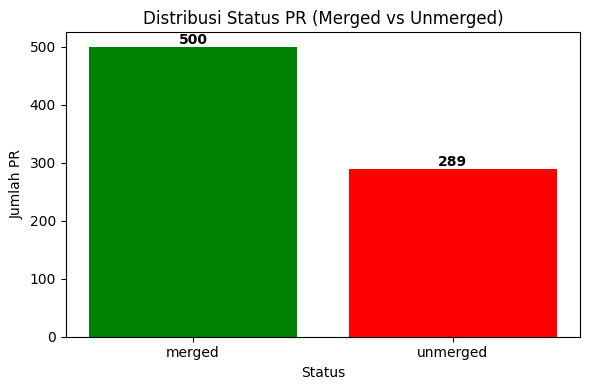

In [33]:
status_counts = df_pr_clean['status'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(status_counts.index, status_counts.values, 
        color=['green', 'red'])
plt.title('Distribusi Status PR (Merged vs Unmerged)')
plt.xlabel('Status')
plt.ylabel('Jumlah PR')
for i, v in enumerate(status_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretasi Q1

Dari total 789 PR yang dianalisis, ada 500 PR (63,4%) yang berhasil di-merge dan 289 PR (36,6%) yang tidak di-merge.

Artinya, peluang sebuah PR diterima di repository `pandas-dev/pandas` sekitar 63%. Jadi, lebih dari setengah kontribusi yang dikirim berhasil diterima. Ini menunjukkan bahwa repo pandas cukup aktif menerima kontribusi, tetapi tetap memiliki proses review yang selektif.

C:\Users\kiranaa\AppData\Local\Temp\ipykernel_20008\3823580173.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([merged, unmerged], labels=['Merged', 'Unmerged'])


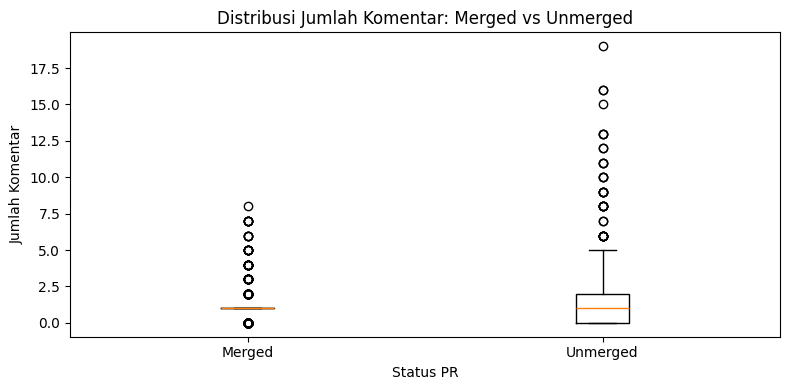

Rata-rata komentar merged: 1.24
Rata-rata komentar unmerged: 2.12


In [34]:
merged = df_pr_clean[df_pr_clean['status'] == 'merged']['comments']
unmerged = df_pr_clean[df_pr_clean['status'] == 'unmerged']['comments']

plt.figure(figsize=(8,4))
plt.boxplot([merged, unmerged], labels=['Merged', 'Unmerged'])
plt.title('Distribusi Jumlah Komentar: Merged vs Unmerged')
plt.xlabel('Status PR')
plt.ylabel('Jumlah Komentar')
plt.tight_layout()
plt.show()

print(f"Rata-rata komentar merged: {merged.mean():.2f}")
print(f"Rata-rata komentar unmerged: {unmerged.mean():.2f}")

## Interpretasi Q2

Dari boxplot terlihat bahwa PR yang unmerge memiliki rata-rata komentar lebih banyak, yaitu 2,12 komentar, sedangkan PR yang merged rata-ratanya hanya 1,24 komentar.

Selain itu, PR unmerged juga punya penyebaran komentar yang lebih besar dan terdapat beberapa PR dengan komentar sangat banyak hingga 18 komentar. Hal ini menunjukkan bahwa PR yang tidak diterima biasanya membutuhkan lebih banyak diskusi, kemungkinan karena ada masalah atau revisi yang belum selesai.

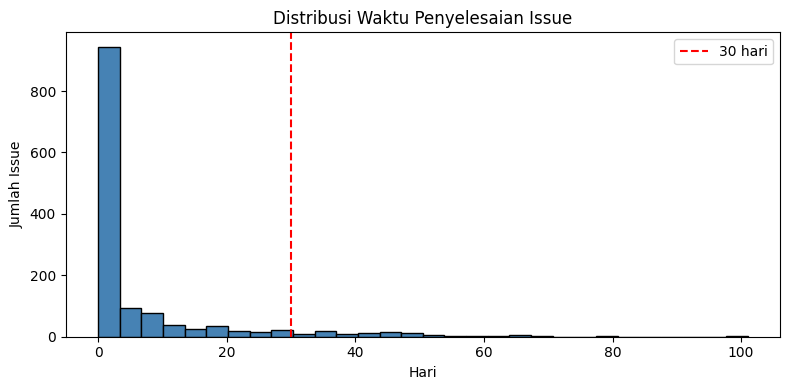

Issue > 30 hari: 94 dari 1362
Proporsi: 6.90%


In [36]:
df_closed = df_issues_clean[df_issues_clean['state'] == 'closed'].copy()
df_closed['days_to_close'] = (df_closed['closed_at'] - df_closed['created_at']).dt.days

plt.figure(figsize=(8,4))
plt.hist(df_closed['days_to_close'], bins=30, color='steelblue', edgecolor='black')
plt.axvline(x=30, color='red', linestyle='--', label='30 hari')
plt.title('Distribusi Waktu Penyelesaian Issue')
plt.xlabel('Hari')
plt.ylabel('Jumlah Issue')
plt.legend()
plt.tight_layout()
plt.show()

lebih_30 = (df_closed['days_to_close'] > 30).sum()
total = len(df_closed)
print(f"Issue > 30 hari: {lebih_30} dari {total}")
print(f"Proporsi: {lebih_30/total:.2%}")

## Interpretasi Q3

Histogram menunjukkan bahwa sebagian besar issue bisa diselesaikan dengan cepat, yaitu sekitar 0–5 hari. Namun, ada beberapa issue yang membutuhkan waktu sangat lama hingga lebih dari 100 hari.

Dari total 1.362 issue yang closed, ada 94 issue (6,9%) yang membutuhkan waktu lebih dari 30 hari untuk ditutup. Artinya, kemungkinan sebuah issue membutuhkan waktu lebih dari 30 hari hanya sekitar 6,9%. Jadi, sebagian besar issue di repository pandas diselesaikan dengan cukup cepat.

## Summary

Data telah dibersihkan dan divisualisasikan.

Temuan utama:
- Probabilitas PR di-merge sekitar **63.4%** →  (Member B, Q1)
- PR unmerged cenderung punya lebih banyak komentar → diuji Member D (Q2)
- **6.9%** issue butuh lebih dari 30 hari untuk ditutup → disimulasi Member E (Q3)

Data bersih tersedia di `data/clean/` untuk dianalisis lebih lanjut oleh Member B, C, D, dan E.